In [1]:
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

from envs.fourrooms import FourRoomsExactValue
from core.config import config 
import gymnax 
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
from core.utils import load_run_data
config, metrics = load_run_data('ppo/20260717_165800/', "FourRooms-misc", results_base_path = "results")

In [4]:
metrics['min_eigenvector_grid'].shape

(1, 30, 13, 13)

In [2]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from IPython.display import HTML

# Prepare data
images = metrics['stat_dist'][0]  
scalars = metrics['SA_min_eigenvalue'].squeeze()

# 1. Setup the figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Initialize image display
im = ax1.imshow(images[0], animated=True)
ax1.set_title("Distribution")

# Initialize line plot
line, = ax2.plot([], [], lw=2)
ax2.set_xlim(0, len(scalars))
ax2.set_ylim(min(scalars), max(scalars))
ax2.set_title("SA Min Eigenvalue")

def update(frame):
    im.set_array(images[frame])
    line.set_data(np.arange(frame + 1), scalars[:frame + 1])
    return im, line

# 2. Create the animation
ani = animation.FuncAnimation(fig, update, frames=len(images), blit=True)

# 3. Close the static plot and display the interactive version
plt.close(fig)
display(HTML(ani.to_jshtml()))

FFmpeg is available: True


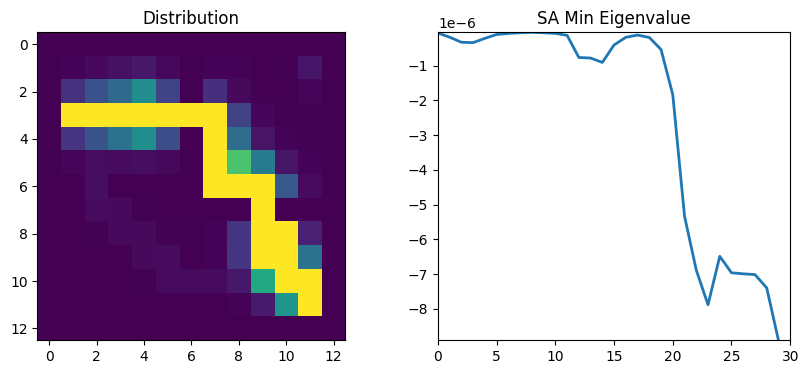

In [5]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Paste the path you found in Step 1 here
plt.rcParams['animation.ffmpeg_path'] = '/opt/homebrew/bin/ffmpeg' 

# Verify it's working
print(f"FFmpeg is available: {animation.writers.is_available('ffmpeg')}")

# Prepare data
images = metrics['stat_dist'][0]  # Shape: (frames, height, width)
scalars = metrics['SA_min_eigenvalue'].squeeze()

# 1. Setup the figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Initialize image display
im = ax1.imshow(images[0], animated=True)
ax1.set_title("Distribution")

# Initialize line plot
line, = ax2.plot([], [], lw=2)
ax2.set_xlim(0, len(scalars))
ax2.set_ylim(min(scalars), max(scalars))
ax2.set_title("SA Min Eigenvalue")

def update(frame):
    # Update image
    im.set_array(images[frame])
    
    # Update line plot (show history up to current frame)
    line.set_data(np.arange(frame + 1), scalars[:frame + 1])
    
    return im, line

# 2. Create the animation
ani = animation.FuncAnimation(fig, update, frames=len(images), blit=True)

# 3. Save the animation
# Requires 'ffmpeg' installed on your system for MP4
ani.save('evolution.mp4', writer='ffmpeg', fps=5)

# Or save as a GIF (requires 'pillow')
# ani.save('evolution.gif', writer='pillow', fps=5)

plt.show()

In [13]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from IPython.display import HTML

# 1. Setup the figure and 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# Initialize image display (Distribution)
im1 = ax1.imshow(metrics['stat_dist'][0, 0], animated=True)
ax1.set_title("Distribution")

# Initialize image display (Min Eigenvalue Grid)
# Assuming metrics['min_eig_grid'] is shape (frames, height, width)
im2 = ax2.imshow(np.abs(metrics['min_eigenvector_grid'][0,0]), animated=True)
ax2.set_title("SA Min Eigenvector")

# Initialize line plot (Scalar Metric)
scalars = metrics['SA_min_eigenvalue'].squeeze()
line, = ax3.plot([], [], lw=2)
ax3.set_xlim(0, len(scalars))
ax3.set_ylim(np.min(scalars), np.max(scalars))
ax3.set_title("SA Min Eigenvalue")

def update(frame):
    # Update both image plots
    im1.set_array(metrics['stat_dist'][0, frame])
    im2.set_array(metrics['min_eigenvector_grid'][0,frame])
    
    # Update line plot
    line.set_data(np.arange(frame + 1), scalars[:frame + 1])
    
    return im1, im2, line

# 2. Create the animation
ani = animation.FuncAnimation(fig, update, frames=len(scalars), blit=True)

# 3. View in Jupyter
plt.close(fig)
display(HTML(ani.to_jshtml()))

Saved successfully.


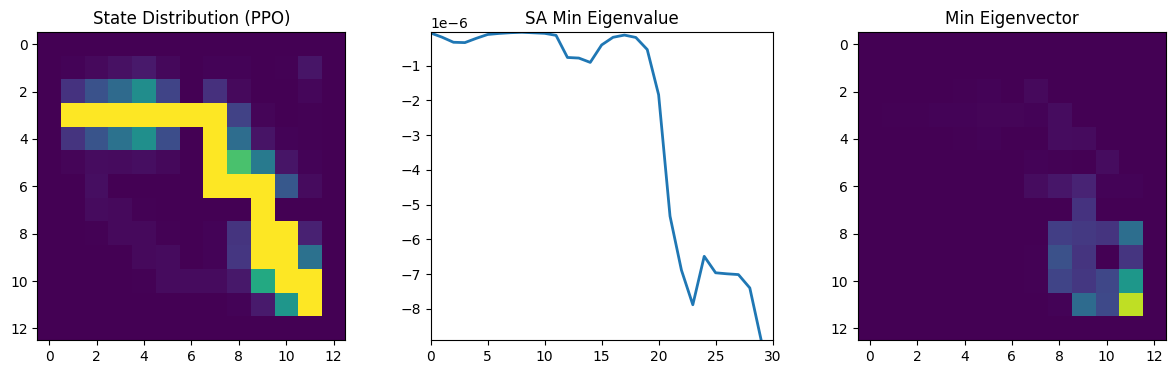

In [11]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# 1. Setup Data
# Ensure index [0] is used to match your initial requirement
dist_data = metrics['stat_dist'][0]
eig_grid = np.abs(metrics['min_eigenvector_grid'][0].squeeze())
scalars = metrics['SA_min_eigenvalue'].squeeze()

# 2. Setup Figure (1 row, 3 columns)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# Setup Plots
im1 = ax1.imshow(dist_data[0], animated=True)
ax1.set_title("State Distribution (PPO)")

line, = ax2.plot([], [], lw=2)
ax2.set_xlim(0, len(scalars))
ax2.set_ylim(np.min(scalars), np.max(scalars))
ax2.set_title("SA Min Eigenvalue")

# The Grid in the third position
im3 = ax3.imshow(eig_grid[0], animated=True)
ax3.set_title("Min Eigenvector")

def update(frame):
    im1.set_array(dist_data[frame])
    line.set_data(np.arange(frame + 1), scalars[:frame + 1])
    im3.set_array(eig_grid[frame])
    return im1, line, im3

ani = animation.FuncAnimation(fig, update, frames=len(scalars), blit=True)

# 3. Save as MP4
# Force the path to ensure it finds your brew-installed ffmpeg
plt.rcParams['animation.ffmpeg_path'] = '/opt/homebrew/bin/ffmpeg' 

# Use 'ffmpeg' writer to save
ani.save('visualization.mp4', writer='ffmpeg', fps=5, dpi=100)

print("Saved successfully.")